# Amazon Sales Data Analysis using SQL

## 1. Introduction & Setup
This notebook focuses on performing Exploratory Data Analysis (EDA) using SQL queries.
The data is loaded from a cleaned CSV file, migrated to a SQLite Database,
and then analyzed to extract business insights.

### 1. Data Migration to SQLite
In this section, we establish a connection to our database using `sqlalchemy` 
and upload the cleaned dataset into a table named `sales`.

In [9]:
import pandas as pd

In [10]:
import sys

In [11]:
sys.path.append('../src')

In [12]:
from db import create_db_engine

In [13]:
df = pd.read_csv('../data/cleaned/amazon_sales_cleaned.csv')

In [14]:
engine = create_db_engine()

In [15]:
df.to_sql('sales', con=engine, if_exists='replace', index=False)

128975

### 2. Data Verification
Fetching the first few records to ensure the table was created correctly and data types are preserved.

In [16]:
result = pd.read_sql("SELECT * FROM sales LIMIT 5", engine)
result

,order_id,date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,size,...,quantity_ordered,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,...,0,INR,647.62,MUMBAI,Maharashtra,400081.0,IN,NaN,0,Easy Ship
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,Kurta,3XL,...,1,INR,406.00,BENGALURU,Karnataka,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,0,Easy Ship
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,Kurta,XL,...,1,INR,329.00,NAVI MUMBAI,Maharashtra,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,1,Unknown
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western_dress,L,...,0,INR,753.33,PUDUCHERRY,Puducherry,605008.0,IN,NaN,0,Easy Ship
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,...,1,INR,574.00,CHENNAI,Tamil_nadu,600073.0,IN,NaN,0,Unknown


### 3. Financial Overview
Calculating the **Total Revenue** generated from all orders that have been successfully shipped.

In [20]:
result2 = pd.read_sql("""
    SELECT SUM(amount * quantity_ordered) AS total_revenue 
    FROM sales 
    WHERE status LIKE 'Shipped%'
""", engine)
result2

,total_revenue
0,71645615.0


### 4. Category Performance
Analyzing which product categories are the most popular based on the total number of orders.

In [28]:
result3 =pd.read_sql("""
             SELECT category, COUNT(*) AS total_orders
             FROM sales   
             GROUP BY category
             ORDER BY total_orders DESC     
                     """,engine)
result3

,category,total_orders
0,Set,50284
1,Kurta,49877
2,Western_dress,15500
3,Top,10622
4,Ethnic_dress,1159
5,Blouse,926
6,Bottom,440
7,Saree,164
8,Dupatta,3


### 5. Top 10 Cities by Order Volume
Identifying the geographical locations with the highest demand to optimize logistics and marketing.

In [ ]:

result4 = pd.read_sql("""
                SELECT ship_city, COUNT(*) AS total_orders
                FROM sales      
                GROUP BY ship_city
                ORDER BY total_orders DESC
                LIMIT 10
                      """,engine)
result4


,ship_city,total_orders
0,BENGALURU,11217
1,HYDERABAD,8074
2,MUMBAI,6126
3,NEW DELHI,5795
4,CHENNAI,5421
5,PUNE,3857
6,KOLKATA,2381
7,GURUGRAM,1868
8,THANE,1701
9,LUCKNOW,1458


### 6. Cancellation Rate by Category
Understanding the cancellation patterns across different categories to identify potential quality or logistics issues.

In [34]:
result5 = pd.read_sql("""
                      SELECT category, COUNT(*) AS total_orders
                      FROM sales
                      WHERE status ='Cancelled'
                      GROUP BY category
                      ORDER BY total_orders DESC
                      LIMIT 1
                """,engine)
result5

,category,total_orders
0,Set,7337


In [37]:
result6 = pd.read_sql("""   
         SELECT category,
            COUNT(*) AS total,
            SUM(CASE WHEN status = 'Cancelled' THEN 1 ELSE 0 END) AS cancelled,
            ROUND(SUM(CASE WHEN status = 'Cancelled' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS cancel_rate
        FROM sales
        GROUP BY category
        ORDER BY cancel_rate DESC
    """, engine)
result6

,category,total,cancelled,cancel_rate
0,Set,50284,7337,14.59
1,Kurta,49877,7255,14.55
2,Western_dress,15500,2122,13.69
3,Bottom,440,60,13.64
4,Saree,164,21,12.80
5,Blouse,926,116,12.53
6,Ethnic_dress,1159,145,12.51
7,Top,10622,1276,12.01
8,Dupatta,3,0,0.00


### 7. Shipping Service Level Analysis
Comparing the average order value between 'Expedited' and 'Standard' shipping to see if premium shipping correlates with higher spending.

In [40]:
result7 = pd.read_sql("""
    SELECT ship_service_level, ROUND(AVG(amount),2) AS avg_order_value
    FROM sales
    GROUP BY ship_service_level
    """,engine)
result7

,ship_service_level,avg_order_value
0,Expedited,612.60
1,Standard,602.27


### 8. Monthly Sales Trends
Tracking Revenue and Order count over time to identify seasonal trends or growth patterns.

In [41]:
result8 = pd.read_sql("""
    SELECT strftime('%Y-%m', date) AS month, 
           SUM(amount) AS revenue,
           COUNT(*) AS orders
    FROM sales
    GROUP BY month
    ORDER BY month
""", engine)
result8

,month,revenue,orders
0,2022-03,101683.85,171
1,2022-04,28838708.32,49067
2,2022-05,26226476.75,42040
3,2022-06,23425809.38,37697


In [51]:
result9 = pd.read_sql("""
    SELECT category, 
           COUNT(*) AS total_orders, 
           SUM(CASE WHEN status LIKE 'Shipped%' THEN 1 ELSE 0 END) AS shipped_orders, 
           SUM(CASE WHEN status = 'Cancelled' THEN 1 ELSE 0 END) AS canceled_orders
    FROM sales
    GROUP BY category
    ORDER BY total_orders DESC
""", engine)
result9

,category,total_orders,shipped_orders,canceled_orders
0,Set,50284,42581,7337
1,Kurta,49877,42301,7255
2,Western_dress,15500,13207,2122
3,Top,10622,9271,1276
4,Ethnic_dress,1159,1007,145
5,Blouse,926,806,116
6,Bottom,440,377,60
7,Saree,164,143,21
8,Dupatta,3,3,0


### 9. Fulfillment Method Comparison
Analyzing how many orders are fulfilled by Amazon versus the Merchant across different shipping levels.

In [52]:
result10 = pd.read_sql("""
    SELECT ship_service_level, 
           COUNT(*) AS total_orders, 
           SUM(CASE WHEN fulfilment  = 'Amazon' THEN 1 ELSE 0 END) AS amazon_fulfilled_orders, 
           SUM(CASE WHEN fulfilment = 'Merchant' THEN 1 ELSE 0 END) AS merchant_fulfilled_orders
    FROM sales
    GROUP BY ship_service_level
    ORDER BY total_orders DESC
""", engine)
result10

,ship_service_level,total_orders,amazon_fulfilled_orders,merchant_fulfilled_orders
0,Expedited,88615,88615,0
1,Standard,40360,1083,39277


In [55]:
result11 = pd.read_sql("""
            SELECT strftime('%Y-%m', date) AS month,   
                COUNT(*) AS total_orders, 
                ROUND(SUM(amount), 2) AS total_revenue,
                ROUND(AVG(amount), 2) AS avg_order_value 
            FROM sales
            GROUP BY month
            ORDER BY month
            """, engine)
result11

,month,total_orders,total_revenue,avg_order_value
0,2022-03,171,101683.85,594.64
1,2022-04,49067,28838708.32,587.74
2,2022-05,42040,26226476.75,623.85
3,2022-06,37697,23425809.38,621.42


## Key Findings:
* **Top Category:** 'Set' and 'Kurta' dominate the sales volume.
* **Top City:** Bengaluru is the leading market for these products.
* **Cancellation Alert:** The 'Set' category has the highest cancellation rate (14.59%), which may require further investigation.

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

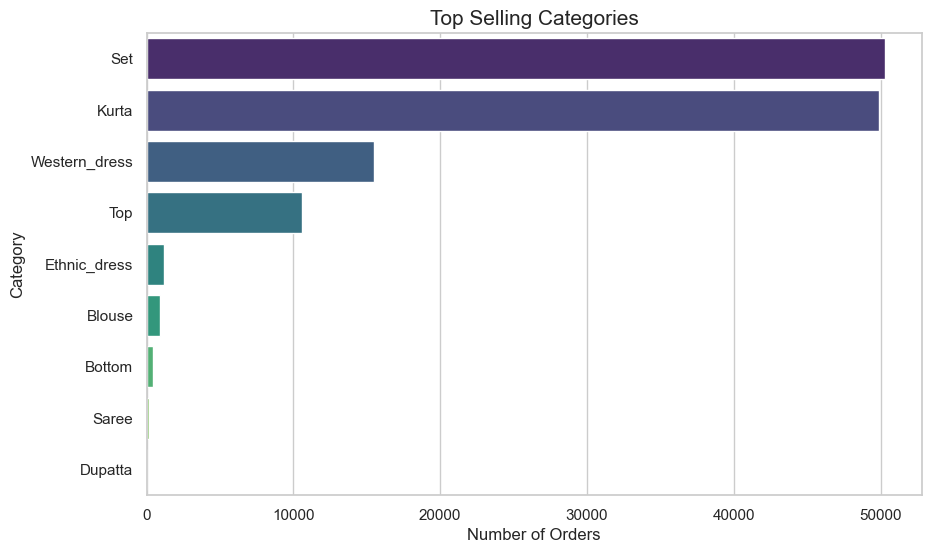

In [69]:
plt.figure(figsize=(10, 6))
sns.barplot(x='total_orders', y='category', hue='category', data=result3, palette='viridis' )

plt.title('Top Selling Categories', fontsize=15)
plt.xlabel('Number of Orders')
plt.ylabel('Category')
plt.show()

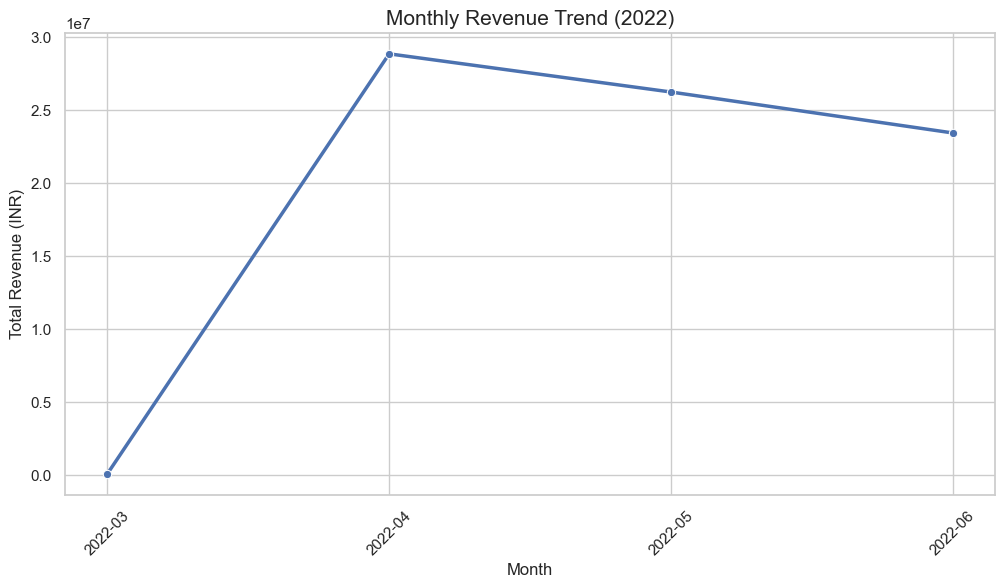

In [70]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='month', y='total_revenue', data=result11, marker='o', color='b', linewidth=2.5)

plt.title('Monthly Revenue Trend (2022)', fontsize=15)
plt.xlabel('Month')
plt.ylabel('Total Revenue (INR)')
plt.xticks(rotation=45)
plt.show()

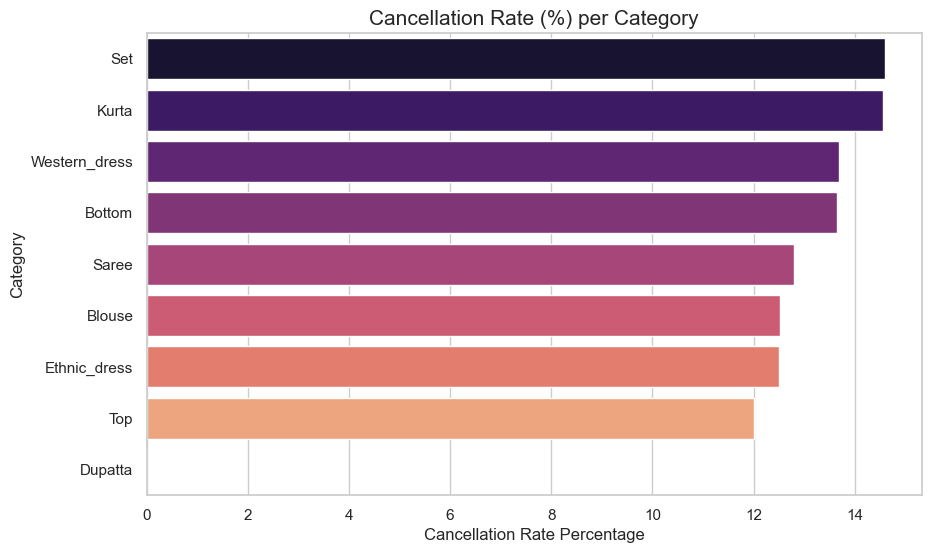

In [71]:
plt.figure(figsize=(10, 6))
sns.barplot(x='cancel_rate', y='category', hue='category', data=result6, palette='magma')

plt.title('Cancellation Rate (%) per Category', fontsize=15)
plt.xlabel('Cancellation Rate Percentage')
plt.ylabel('Category')
plt.show()